# Notebook de suivi — prototypage RL sur `toy_lob`

Ce notebook sert à **documenter la progression du projet** et à **tester les briques principales** déjà implémentées.

Ordre retenu :
1. visualiser le marché simplifié `toy_lob` ;
2. valider la collecte d'une trajectoire ;
3. tester un épisode complet Actor–Critic ;
4. observer l'entraînement Actor–Critic sur plusieurs épisodes ;
5. observer l'entraînement PPO sur plusieurs épisodes ;
6. construire et analyser les nouvelles features de marché.

L'objectif de cette phase n'est **pas** encore d'obtenir une stratégie réaliste, mais de valider l'ossature RL sur un environnement volontairement simplifié.

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root:", project_root)

Project root: /Users/franciscegoat/mm-rl


In [2]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.envs.env_toy_mm import MMSimulator
from src.ppo.networks import ActorNet, CriticNet
from src.utils.device import get_device
from src.utils.visualisation import plot_lob
from src.features.market_features import build_market_features

import scripts.train_loop as tr_lp

device = get_device()
print("Device:", device)

[Device] Using mps
[Device] Using mps
Device: mps


## Étape 1 — Visualisation du `toy_lob`

On commence par regarder **la structure du marché simulé** : mid-price, bid, ask, spread et signal d'imbalance.

### Note carnet de suivi
Le marché simplifié est utilisé ici comme **support de prototypage**. L'enjeu n'est pas encore la fidélité microstructurelle, mais la mise en place d'un pipeline RL complet.

In [3]:
market = pd.read_csv("data/raw/toy_lob.csv")
market.head()

,mid,bid,ask,bid_vol,ask_vol
0,100.000000,99.995000,100.005000,8,15
1,100.062333,100.057333,100.067333,4,5
2,100.044971,100.039971,100.049971,11,9
3,100.126287,100.121287,100.131287,8,11
4,100.317655,100.312655,100.322655,8,16


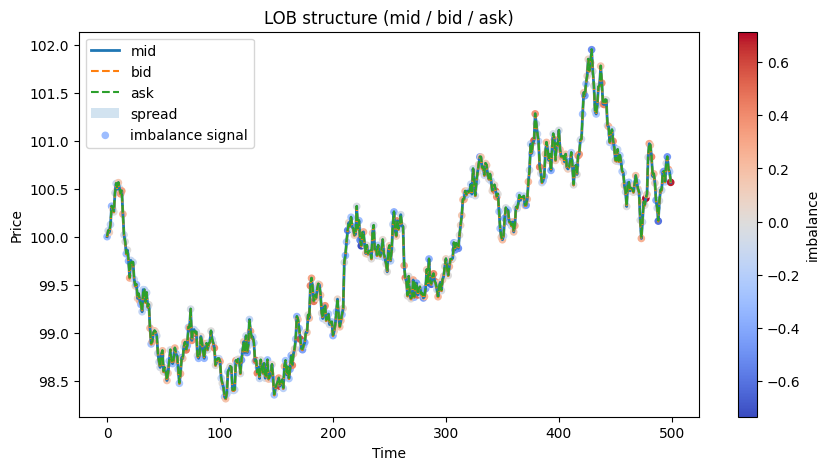

In [4]:
plot_lob(market, n_points=500)

## Étape 2 — Validation de `collect_trajectory`

On vérifie qu'une trajectoire complète peut être collectée sous la politique courante, avec des tenseurs cohérents pour :
- `states`
- `actions`
- `rewards`
- `old_log_probs`

### Note carnet de suivi
La collecte de trajectoire constitue le point de jonction entre :
- la politique (`ActorNet`) ;
- l'environnement (`MMSimulator`) ;
- les boucles d'entraînement.

In [5]:
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

actor = ActorNet(
    state_dim= env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

In [6]:
trajectory = tr_lp.collect_trajectory(
    env=env,
    model=actor,
    device=device,
    reset_rdm=True,
    max_steps=200
)

states = trajectory["states"]
actions = trajectory["actions"]
rewards = trajectory["rewards"]
old_log_probs = trajectory["old_log_probs"]

print("Shapes :")
print("states       :", states.shape)
print("actions      :", actions.shape)
print("rewards      :", rewards.shape)
print("log_probs    :", old_log_probs.shape)

print("\nTypes :")
print("states       :", states.dtype, states.device)
print("actions      :", actions.dtype, actions.device)
print("rewards      :", rewards.dtype, rewards.device)
print("log_probs    :", old_log_probs.dtype, old_log_probs.device)

print("\nSanity checks :")
print("nb steps     :", len(rewards))
print("reward mean  :", rewards.mean().item())
print("reward std   :", rewards.std().item())
print("action range :", actions.min().item(), ",", actions.max().item())

assert not torch.isnan(states).any()
assert not torch.isnan(actions).any()
assert not torch.isnan(rewards).any()
assert not torch.isnan(old_log_probs).any()
print("\nTests simples passés.")

Shapes :
states       : torch.Size([200, 4])
actions      : torch.Size([200, 1])
rewards      : torch.Size([200])
log_probs    : torch.Size([200, 1])

Types :
states       : torch.float32 mps:0
actions      : torch.float32 mps:0
rewards      : torch.float32 mps:0
log_probs    : torch.float32 mps:0

Sanity checks :
nb steps     : 200
reward mean  : 0.011027703061699867
reward std   : 0.0812687799334526
action range : 0.00146683759521693 , 0.04860369488596916

Tests simples passés.


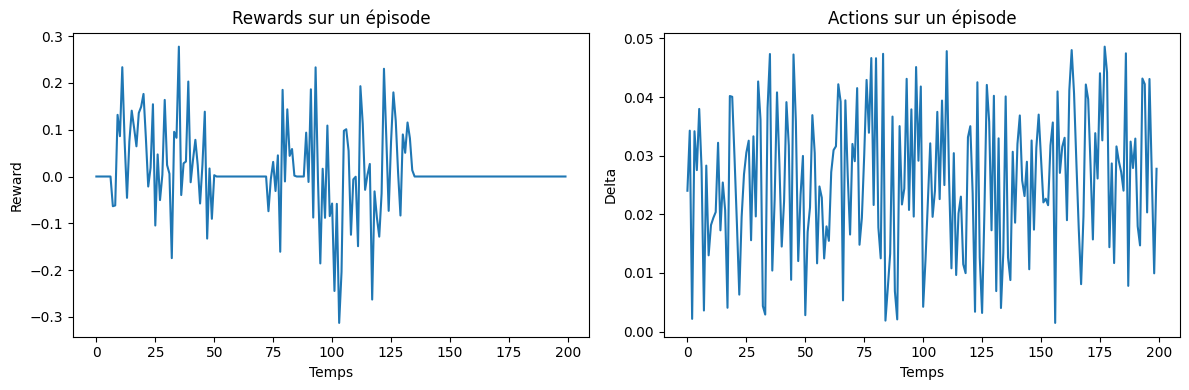

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rewards.cpu().numpy())
plt.title("Rewards sur un épisode")
plt.xlabel("Temps")
plt.ylabel("Reward")

plt.subplot(1, 2, 2)
plt.plot(actions.cpu().numpy())
plt.title("Actions sur un épisode")
plt.xlabel("Temps")
plt.ylabel("Delta")

plt.tight_layout()
plt.show()

## Étape 3 — Test d'un épisode complet Actor–Critic

On valide ici le pipeline local :
1. collecte ;
2. calcul des returns ;
3. entraînement du critic ;
4. calcul des avantages ;
5. entraînement de l'acteur.

### Note carnet de suivi
Cette étape correspond à la fermeture d'une première boucle **Actor–Critic simple**, avant l'introduction de PPO.

In [8]:
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

actor = ActorNet(
    state_dim= env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

t0 = time.time()

l_history_critic, l_history_actor, episode_return = tr_lp.train_one_episode(
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=True,
)

elapsed = time.time() - t0

print("\n--- Résumé test train_one_episode ---")
print("critic history length :", len(l_history_critic))
print("actor history length  :", len(l_history_actor))
print("critic last loss      :", l_history_critic[-1])
print("actor last loss       :", l_history_actor[-1])
print("episode return        :", episode_return)
print("elapsed time          :", elapsed)

assert len(l_history_critic) == 5
assert len(l_history_actor) == 5
assert not torch.isnan(torch.tensor(l_history_critic)).any()
assert not torch.isnan(torch.tensor(l_history_actor)).any()
print("Tests simples passés.")

[train_critic]
[fit_critic] epoch=1/5 loss=1.7283e+00
[train_actor]
[fit_actor] epoch=1/5 loss=-9.1491e-03

--- Résumé test train_one_episode ---
critic history length : 5
actor history length  : 5
critic last loss      : 1.2322810888290405
actor last loss       : -0.024179644882678986
episode return        : tensor(-2.6175, device='mps:0')
elapsed time          : 0.6878921985626221
Tests simples passés.


## Étape 4 — Entraînement sur plusieurs épisodes : Actor–Critic classique

On observe ici le comportement de la version **sans clipping PPO**.

### Note carnet de suivi
Cette étape a permis de mettre en évidence une forte instabilité de l'Actor–Critic classique dans cet environnement simplifié.

In [9]:
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

t0 = time.time()

history_ac = tr_lp.train_actor_critic(
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=50,
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=False
)

elapsed = time.time() - t0
print("Temps total :", elapsed)

critic_loss_ac = history_ac["critic_loss"]
actor_loss_ac = history_ac["actor_loss"]
returns_ac = history_ac["episode_return"]

print("\n--- Sanity checks ---")
print("Nb épisodes :", len(returns_ac))
print("Critic loss (last) :", critic_loss_ac[-1])
print("Actor loss  (last) :", actor_loss_ac[-1])
print("Return moyen :", sum(returns_ac)/len(returns_ac))
print("Return min / max :", min(returns_ac), max(returns_ac))

Temps total : 28.813791036605835

--- Sanity checks ---
Nb épisodes : 50
Critic loss (last) : 0.6854289770126343
Actor loss  (last) : 0.03304041549563408
Return moyen : tensor(0.0116)
Return min / max : tensor(-8.4765) tensor(14.4367)


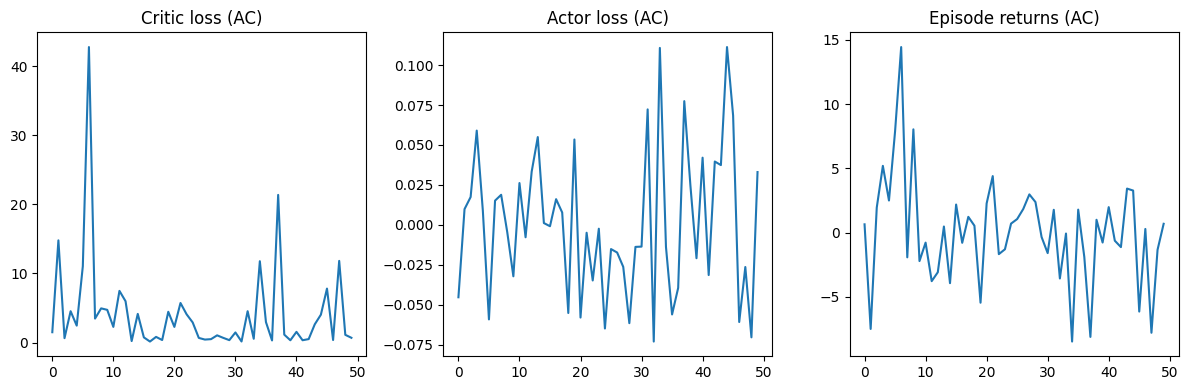

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(critic_loss_ac)
plt.title("Critic loss (AC)")

plt.subplot(1, 3, 2)
plt.plot(actor_loss_ac)
plt.title("Actor loss (AC)")

plt.subplot(1, 3, 3)
plt.plot(returns_ac)
plt.title("Episode returns (AC)")

plt.tight_layout()
plt.show()

## Étape 5 — Entraînement sur plusieurs épisodes : PPO

On remplace ici la perte actor simple par la perte PPO clipée.

### Note carnet de suivi
Le passage à PPO stabilise nettement l'apprentissage de l'acteur, même si le signal de reward reste bruité dans le cadre du `toy_lob`.

In [11]:
env = MMSimulator(csv_path="data/raw/toy_lob.csv", seed=42)

actor = ActorNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3,
    action_dim=1,
    delta_min=0.0,
    delta_max=0.05
).to(device)

critic = CriticNet(
    state_dim=env.state_dim,
    hidden_size=64,
    n_layers=3
).to(device)

actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=3e-4)

t0 = time.time()

history_ppo = tr_lp.train_ppo(
    env=env,
    actor=actor,
    critic=critic,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    device=device,
    gamma=0.99,
    n_episodes=50,
    n_epochs_actor=5,
    n_epochs_critic=5,
    random_reset=True,
    max_steps=200,
    verbose=False
)

elapsed = time.time() - t0
print("Temps total :", elapsed)

critic_loss_ppo = history_ppo["critic_loss"]
actor_loss_ppo = history_ppo["actor_loss"]
returns_ppo = history_ppo["episode_return"]

print("\n--- Sanity checks ---")
print("Nb épisodes :", len(returns_ppo))
print("Critic loss (last) :", critic_loss_ppo[-1])
print("Actor loss  (last) :", actor_loss_ppo[-1])
print("Return moyen :", sum(returns_ppo)/len(returns_ppo))
print("Return min / max :", min(returns_ppo), max(returns_ppo))

Temps total : 18.464757204055786

--- Sanity checks ---
Nb épisodes : 50
Critic loss (last) : 3.133324146270752
Actor loss  (last) : -0.00284628220833838
Return moyen : 0.8366305738687515
Return min / max : -9.73628044128418 19.53491973876953


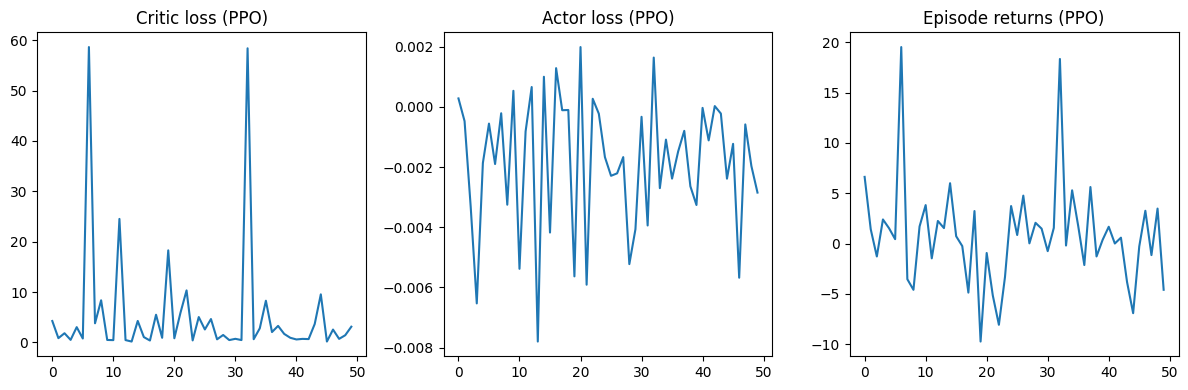

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(critic_loss_ppo)
plt.title("Critic loss (PPO)")

plt.subplot(1, 3, 2)
plt.plot(actor_loss_ppo)
plt.title("Actor loss (PPO)")

plt.subplot(1, 3, 3)
plt.plot(returns_ppo)
plt.title("Episode returns (PPO)")

plt.tight_layout()
plt.show()

## Étape 6 — Construction des nouvelles features de marché

On enrichit ici les données brutes avec :
- `spread`
- `imbalance`
- `microprice`
- `return_1`
- `ma_10`
- `ma_20`
- `rsi_14`

### Note carnet de suivi
Ces features rapprochent l'état de l'esprit de l'article, même si le marché jouet reste trop pauvre pour qu'elles deviennent réellement prédictives.

In [13]:
df_feat = build_market_features(market)
df_feat.head()

,mid,bid,ask,bid_vol,ask_vol,spread,imbalance,microprice,return_1,ma_10,ma_20,rsi_14
0,100.000000,99.995000,100.005000,8.0,15.0,0.01,-0.304348,99.998478,0.000000,100.000000,100.000000,0.000000
1,100.062333,100.057333,100.067333,4.0,5.0,0.01,-0.111111,100.061778,0.062333,100.031167,100.031167,100.000000
2,100.044971,100.039971,100.049971,11.0,9.0,0.01,0.100000,100.045471,-0.017362,100.035768,100.035768,78.214740
3,100.126287,100.121287,100.131287,8.0,11.0,0.01,-0.157895,100.125498,0.081316,100.058398,100.058398,89.217015
4,100.317655,100.312655,100.322655,8.0,16.0,0.01,-0.333333,100.315989,0.191368,100.110249,100.110249,95.072984


In [14]:
print(df_feat[["mid", "spread", "imbalance", "microprice", "return_1", "ma_10", "ma_20", "rsi_14"]].describe())

                mid        spread     imbalance    microprice      return_1  \
count  10000.000000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean     102.069233  1.000000e-02     -0.002606    102.069220     -0.000349   
std        6.299184  1.224576e-14      0.229400      6.299214      0.128625   
min       91.508282  1.000000e-02     -1.000000     91.509711     -0.478503   
25%       96.894763  1.000000e-02     -0.157895     96.894439     -0.086273   
50%      100.445531  1.000000e-02      0.000000    100.444557     -0.000345   
75%      108.767010  1.000000e-02      0.153846    108.766484      0.084872   
max      114.692521  1.000000e-02      0.857143    114.691921      0.549181   

              ma_10         ma_20        rsi_14  
count  10000.000000  10000.000000  10000.000000  
mean     102.070812    102.072604     49.910619  
std        6.296168      6.293118     15.916419  
min       91.687731     91.834155      0.000000  
25%       96.917547     96.941590     

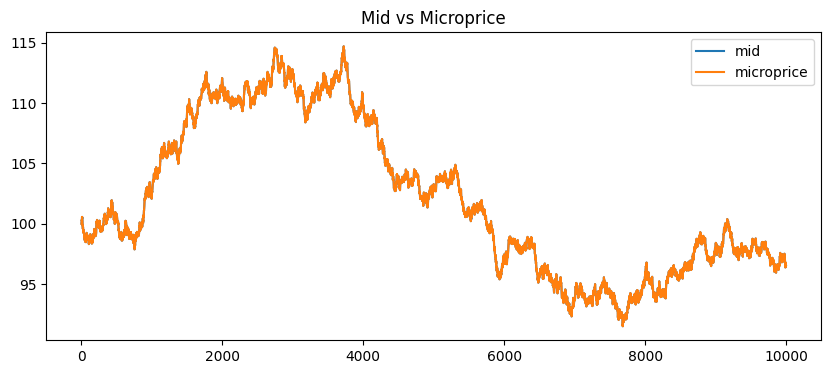

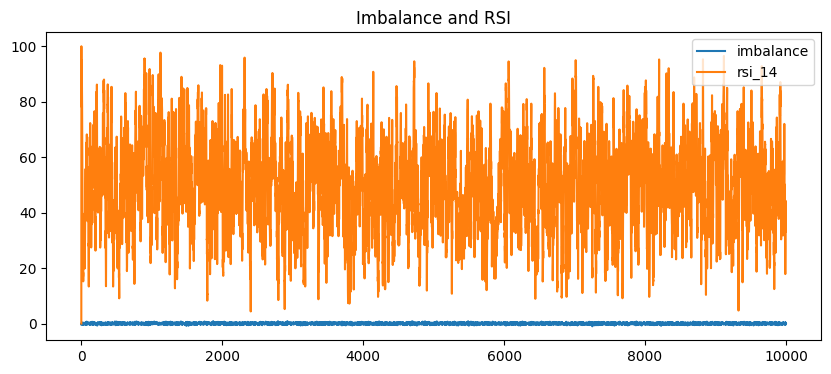

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(df_feat["mid"], label="mid")
plt.plot(df_feat["microprice"], label="microprice")
plt.legend()
plt.title("Mid vs Microprice")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df_feat["imbalance"], label="imbalance")
plt.plot(df_feat["rsi_14"], label="rsi_14")
plt.legend()
plt.title("Imbalance and RSI")
plt.show()

## Conclusion provisoire

À ce stade :

- le **pipeline RL** est en place ;
- la **collecte de trajectoires** fonctionne ;
- l'**Actor–Critic classique** est instable dans ce cadre ;
- **PPO** stabilise nettement mieux les mises à jour ;
- les **features de marché enrichies** sont construites, mais encore peu informatives dans le `toy_lob`.

La suite logique du projet n'est plus l'algorithme RL lui-même, mais l'**enrichissement du simulateur** :
1. rendre l'état plus informatif ;
2. coupler plus fortement carnet et dynamique de prix ;
3. enrichir l'espace d'action.